In [4]:
import pandas as pd
import numpy as np

In [5]:
!ls

README.md              lecture_code_and_data  requirements.txt
checkpoints            logs                   shopify.ipynb
di_sample31424 (3).csv notes                  src
evaluation             pictures               swanlog
experiment_code        pyproject.toml         tests
inference_generation   pytest.ini             train


In [6]:
raw_df = pd.read_csv("di_sample31424 (3).csv")

In [7]:
raw_df.head()

,shop_plan,session_duration_bucket,reporting_year,week_of_reporting_year,year_week,month,shops,number_of_sessions,sessions_with_products_added_to_cart,sessions_with_checkout,checkout_completed
0,Pro,1. 0,2021,1,2021-01,January,1318,3485266,640,4261,7312
1,Platinum,1. 0,2021,1,2021-01,January,2787,17155815,5706,44118,15678
2,Basic,1. 0,2021,1,2021-01,January,42257,7942711,2718,5581,9762
3,Others,1. 0,2021,1,2021-01,January,34094,1120595,188,797,711
4,Advanced,1. 0,2021,1,2021-01,January,8527,7185250,1058,6360,11700


In [8]:
spike_year = 2023
start_spike_0 = 15
start_spike = 25
end_spike = 35

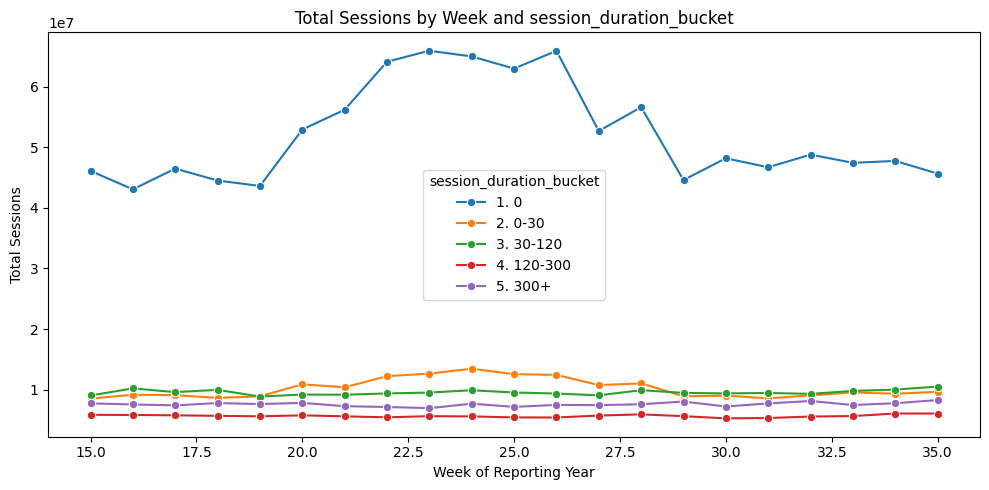

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_df = raw_df[(raw_df['reporting_year'] == spike_year) & (raw_df['week_of_reporting_year'].between(start_spike_0, end_spike))]
agg_df = (
    filtered_df
    .groupby(['week_of_reporting_year', 'session_duration_bucket'], as_index=False)['number_of_sessions']
    .sum()
    .rename(columns={'number_of_sessions': 'total_sessions'})
    .sort_values(['week_of_reporting_year', 'session_duration_bucket'])
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=agg_df,
    x='week_of_reporting_year',
    y='total_sessions',
    hue='session_duration_bucket',
    marker='o'
)
plt.title('Total Sessions by Week and session_duration_bucket')
plt.xlabel('Week of Reporting Year')
plt.ylabel('Total Sessions')
plt.tight_layout()


In [10]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install 